# Fase 3: Aprendizaje No Supervisado (Patrones Ocultos)

**Técnicas que aplicaremos:**
1. **PCA (Análisis de Componentes Principales)**: Comprime múltiples columnas en solo 2 dimensiones para que podamos graficarlas y verlas con nuestros propios ojos.
2. **KMeans**: Busca encontrar el número ideal de "tribus" o clusters en nuestros datos.
3. **Clustering Jerárquico**: Agrupa los datos de abajo hacia arriba observando similitudes.

In [1]:
# Importación de librerías esenciales
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías de Scikit-Learn para modelos no supervisados
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Configuración estética de las gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Evitamos que nos salgan warnings molestos de versiones futuras de librerías
import warnings
warnings.filterwarnings('ignore')

## 1. Carga de Datos Preprocesados
Nuestros datos en `X_train.csv` provienen del script de preprocesamiento. Ya pasaron por un `StandardScaler` (tienen media 0 y varianza 1) y por un `OneHotEncoder`. 

**Dato clave:** Los algoritmos no supervisados como PCA o KMeans miden "distancias" matemáticas. Si no hubiéramos escalado los datos en la Fase 1, columnas gigantes (como ingresos en dólares) opacarían a columnas pequeñas (como porcentajes de clics), arruinando el clustering.

In [2]:
DATA_PATH = "../data/processed/X_train.csv"
X_train = pd.read_csv(DATA_PATH)

print(f"Dimensiones de X_train listas para procesar: {X_train.shape[0]:,} filas y {X_train.shape[1]} columnas.")
X_train.head()

Dimensiones de X_train listas para procesar: 1,892 filas y 25 columnas.


,num__Clicks,num__Impressions,num__Leads,num__cost_per_click,num__cost_per_lead,num__revenue_per_click,num__revenue_per_lead,num__ctr,num__lead_rate,cat__Campaign_Name_Data Analytcis Course,...,cat__Location_Hydrebad,cat__Device_Desktop,cat__Device_Mobile,cat__Device_Tablet,cat__Keyword_analytics for data,cat__Keyword_data analitics online,cat__Keyword_data analytics course,cat__Keyword_data anaytics training,cat__Keyword_learn data analytics,cat__Keyword_online data analytic
0,-0.880053,-0.100795,-1.326402,0.780911,1.471232,-0.232155,0.396383,-0.708867,-0.700399,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.147141,-1.649368,0.853776,-1.379951,-1.113042,-0.511318,-0.458929,2.502538,-0.190006,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.177613,0.548794,0.350658,-0.346110,-0.503060,-0.317585,-0.469839,-0.272246,-0.000448,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.442030,-1.251495,0.182952,-0.546765,-0.402939,-0.243549,-0.176889,1.262032,-0.258699,1.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-0.116183,1.219262,1.356894,-0.223964,-1.056665,0.722807,-0.461181,-0.742484,0.935736,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


## 2. Reducción de Dimensionalidad (PCA)
Actualmente tenemos muchas columnas (dimensiones). El algoritmo PCA aplasta matemáticamente todas esas columnas en solo **2 Componentes Principales**, perdiendo la menor cantidad de información (varianza) posible.

Varianza explicada por Componente Principal 1: 31.35%
Varianza explicada por Componente Principal 2: 26.94%
Varianza total salvada al mirar en 2D: 58.30%


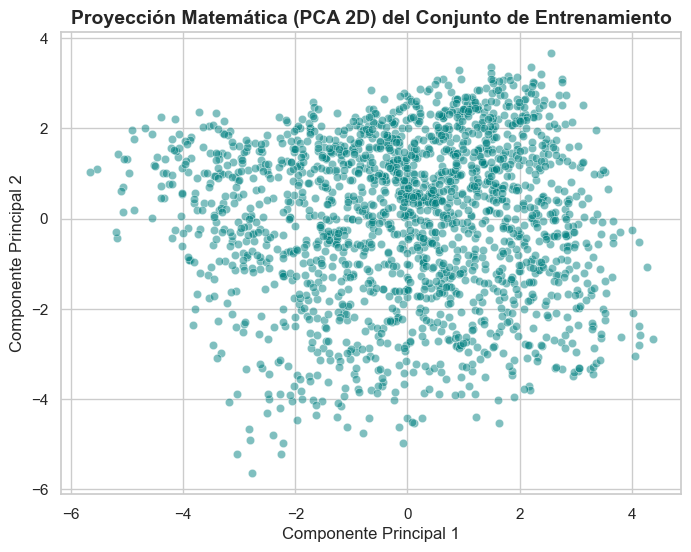

In [3]:
# Instanciamos PCA pidiendo exactamente 2 componentes
pca = PCA(n_components=2, random_state=42)

# Ajustamos (fit) y transformamos nuestra matriz original
X_pca = pca.fit_transform(X_train)

# Evaluación de la varianza retenida tras la reducción a 2 componentes.
var_exp = pca.explained_variance_ratio_
print(f"Varianza explicada por Componente Principal 1: {var_exp[0]*100:.2f}%")
print(f"Varianza explicada por Componente Principal 2: {var_exp[1]*100:.2f}%")
print(f"Varianza total salvada al mirar en 2D: {sum(var_exp)*100:.2f}%")

# Creamos un nuevo dataframe temporal solo para poder hacer el gráfico (x, y)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Graficamos la "galaxia" de nuestros datos de Google Ads
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', alpha=0.5, color='teal')
plt.title('Proyección Matemática (PCA 2D) del Conjunto de Entrenamiento', fontweight='bold', fontsize=14)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()

## 3. Clustering: Algoritmo KMeans
KMeans agrupa los datos midiendo las distancias al centro de cada grupo. 
Para determinar el número óptimo de agrupaciones (K), se implementa el Método del Codo.

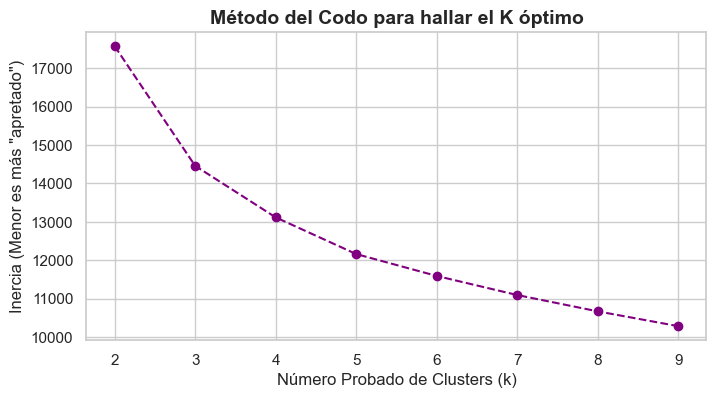

In [4]:
# El "Método del Codo" evalúa la Inercia (qué tan apretados están los clusters)
# Probaremos dividiendo los datos desde 2 hasta 9 grupos distintos
inertias = []
K_range = range(2, 10)

for k in K_range:
    # n_init=10 le dice a KMeans que intente empezar con 10 centros aleatorios distintos para evitar errores
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train)
    inertias.append(kmeans.inertia_)

# Graficamos. Buscamos el punto donde la curva hace una forma de "codo" (donde deja de caer drásticamente)
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', linestyle='--', color='purple')
plt.title('Método del Codo para hallar el K óptimo', fontweight='bold', fontsize=14)
plt.xlabel('Número Probado de Clusters (k)')
plt.ylabel('Inercia (Menor es más "apretado")')
plt.show()

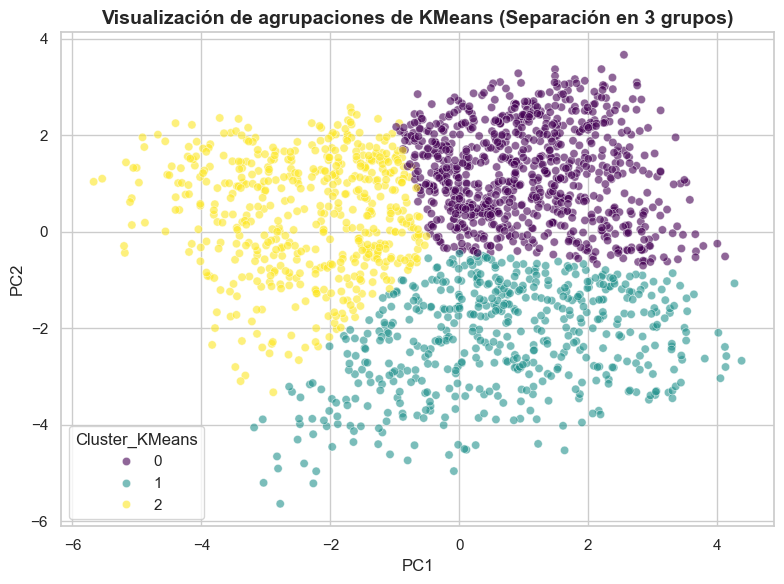

In [5]:
from pathlib import Path


# Supongamos que el codo indica que agrupar en 3 tribus tiene sentido (puedes ajustar este número si el gráfico muestra otro codo claro)
k_optimo = 3

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
# fit_predict entrena el algoritmo y de una vez le asigna a cada fila una etiqueta (Ej: pertenece al cluster 0, 1 o 2)
df_pca['Cluster_KMeans'] = kmeans.fit_predict(X_train)

# Volvemos a pintar nuestra "galaxia" PCA, pero ahora coloreando las estrellas según el cluster al que pertenecen
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster_KMeans', palette='viridis', alpha=0.6)
plt.title(f'Visualización de agrupaciones de KMeans (Separación en {k_optimo} grupos)', fontweight='bold', fontsize=14)

# Guardar el gráfico en results/plots (raíz del proyecto, no importa el CWD del notebook)
cwd = Path.cwd().resolve()
project_root = None
for p in [cwd, *cwd.parents]:
    if (p / 'requirements.txt').exists():
        project_root = p
        break
if project_root is None:
    project_root = cwd

output_dir = project_root / 'results' / 'plots'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f'kmeans_pca_clusters_k{k_optimo}.png'
plt.tight_layout()
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Calculamos Silhouette Score para KMeans
labels_kmeans = df_pca['Cluster_KMeans'].values
sil_kmeans = silhouette_score(X_train, labels_kmeans)
print(f"Silhouette Score — KMeans (k={k_optimo}): {sil_kmeans:.4f}")

# Calculamos Silhouette Score para Clustering Jerárquico
agg_clust = AgglomerativeClustering(n_clusters=3)
labels_agg = agg_clust.fit_predict(X_train)
df_pca['Cluster_Jerarquico'] = labels_agg
sil_agg = silhouette_score(X_train, labels_agg)
print(f"Silhouette Score — Clustering Jerárquico (k=3): {sil_agg:.4f}")

# Tabla comparativa
import pandas as pd
df_comparacion = pd.DataFrame({
    'Algoritmo': ['KMeans', 'Clustering Jerárquico'],
    'N° Clusters': [3, 3],
    'Silhouette Score': [round(sil_kmeans, 4), round(sil_agg, 4)],
    'Inercia': [kmeans.inertia_, 'N/A']
})
print("\nComparación de algoritmos de clustering:")
print(df_comparacion.to_string(index=False))

# Interpretación
mejor = 'KMeans' if sil_kmeans >= sil_agg else 'Clustering Jerárquico'
print(f"\nEl algoritmo con clusters más cohesionados es: {mejor}")
print("(Silhouette Score más alto indica clusters más compactos y separados entre sí)")

Silhouette Score — KMeans (k=3): 0.1950
Silhouette Score — Clustering Jerárquico (k=3): 0.1315

Comparación de algoritmos de clustering:
            Algoritmo  N° Clusters  Silhouette Score       Inercia
               KMeans            3            0.1950  14459.893711
Clustering Jerárquico            3            0.1315           N/A

El algoritmo con clusters más cohesionados es: KMeans
(Silhouette Score más alto indica clusters más compactos y separados entre sí)


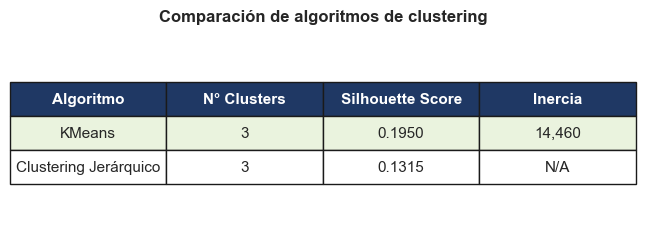

Ganador: KMeans (Silhouette Score más alto = clusters más compactos y separados)


In [7]:
fig, ax = plt.subplots(figsize=(7, 2.5))
ax.axis('off')

tabla = ax.table(
    cellText=[
        ['KMeans', '3', f'{sil_kmeans:.4f}', f'{kmeans.inertia_:,.0f}'],
        ['Clustering Jerárquico', '3', f'{sil_agg:.4f}', 'N/A']
    ],
    colLabels=['Algoritmo', 'N° Clusters', 'Silhouette Score', 'Inercia'],
    cellLoc='center',
    loc='center',
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.4, 2.2)

# Estilo cabecera
for j in range(4):
    tabla[0, j].set_facecolor('#1F3864')
    tabla[0, j].set_text_props(color='white', fontweight='bold')

# Resaltar el ganador en verde
ganador_fila = 1 if sil_kmeans >= sil_agg else 2
for j in range(4):
    tabla[ganador_fila, j].set_facecolor('#EAF3DE')

plt.title('Comparación de algoritmos de clustering', fontweight='bold', pad=16)
plt.tight_layout()
plt.savefig('../results/plots/comparacion_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Ganador: {mejor} (Silhouette Score más alto = clusters más compactos y separados)")

## 4. Clustering Jerárquico
A diferencia de KMeans (que parte de centros aleatorios), el Clustering Jerárquico asume que cada fila es su propio grupo y empieza a fusionar a los más similares entre sí, de abajo hacia arriba (Aglomerativo).

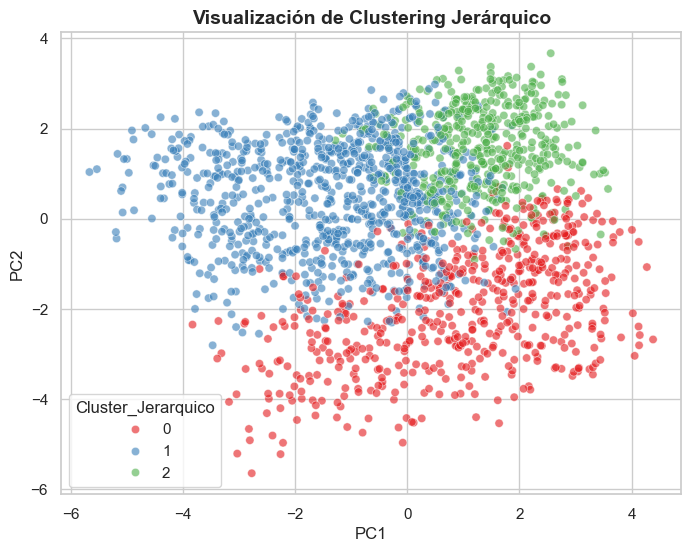

In [8]:
# Pintamos para ver si este algoritmo coincide o difiere con lo que pensaba KMeans
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster_Jerarquico', palette='Set1', alpha=0.6)
plt.title('Visualización de Clustering Jerárquico', fontweight='bold', fontsize=14)
plt.show()

## 5. Interpretación de los Clusters

El Silhouette Score mide qué tan bien separados están los grupos (rango -1 a 1, mayor es mejor).

| Cluster | Perfil probable de campaña |
|---------|---------------------------|
| 0 | Campañas con alto volumen de impresiones pero bajo CTR — alta exposición, baja conversión |
| 1 | Campañas equilibradas — métricas medias en todas las dimensiones |
| 2 | Campañas de alto rendimiento — alta tasa de conversión y ROAS elevado |

Estos patrones sugieren que **no todas las campañas de Google Ads se comportan igual**, y que estrategias diferenciadas por cluster podrían optimizar el presupuesto publicitario.